# Keras Tuner for Hyperparameter Optimization

The Keras Tuner for Hyperparameter Optimization Colab demonstrates:

- Uses RandomSearch tuner from keras_tuner

- Tunes convolutional filters, dense units, dropout rate, and learning rate

- Evaluates and prints the best performing model and its hyperparameters

## Setup & Imports

In [ ]:
!pip install keras-tuner

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from IPython.display import Markdown, display

## Load and Preprocess Data

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

x_train_small = x_train[:10000]
y_train_small = y_train[:10000]

tuner.search(x_train_small, y_train_small, validation_split=0.2, epochs=5)


Trial 5 Complete [00h 06m 53s]
val_accuracy: 0.9559999704360962

Best val_accuracy So Far: 0.9915833473205566
Total elapsed time: 01h 11m 07s


## Build Model Function for Tuning

In [ ]:
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Conv2D(
        filters=hp.Int('conv1_filters', min_value=32, max_value=128, step=32),
        kernel_size=3,
        activation='relu',
        input_shape=(28, 28, 1)))
    model.add(layers.MaxPooling2D(2))

    model.add(layers.Conv2D(
        filters=hp.Int('conv2_filters', min_value=32, max_value=128, step=32),
        kernel_size=3,
        activation='relu'))
    model.add(layers.MaxPooling2D(2))

    model.add(layers.Flatten())
    model.add(layers.Dense(
        units=hp.Int('dense_units', min_value=64, max_value=256, step=64),
        activation='relu'))
    model.add(layers.Dropout(hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'])

    return model

## Set Up the Tuner

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=3,
    directory='kt_dir',
    project_name='mnist_tuning')

Reloading Tuner from kt_dir/mnist_tuning/tuner0.json


## Search for Best Hyperparameters

In [ ]:
tuner.search(x_train, y_train, epochs=5, validation_split=0.2)

## Evaluate the Best Model

In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
loss, acc = best_model.evaluate(x_test, y_test)
print(f"Best model test accuracy: {acc:.4f}")

best_hps = tuner.get_best_hyperparameters(1)[0]

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9920 - loss: 0.0286
Best model test accuracy: 0.9936


## Display Best Hyperparameters

In [ ]:
def show_hyperparams(hp):
    md = "### 🔍 Best Hyperparameters\n\n"
    for k in hp.values:
        md += f"- **{k}**: `{hp.get(k)}`\n"
    display(Markdown(md))

show_hyperparams(best_hps)

### 🔍 Best Hyperparameters

- **conv1_filters**: `128`
- **conv2_filters**: `64`
- **dense_units**: `256`
- **dropout_rate**: `0.5`
- **learning_rate**: `0.001`


## Visualize Top Trials' Scores

In [ ]:
# Extract best trials
tuner_results = pd.DataFrame([
    {
        "Trial": t.trial_id,
        "Score": t.score,
        **t.hyperparameters.values
    } for t in tuner.oracle.get_best_trials(num_trials=10)
])

In [ ]:
# Sort by score
tuner_results = tuner_results.sort_values("Score", ascending=False)

## Plot

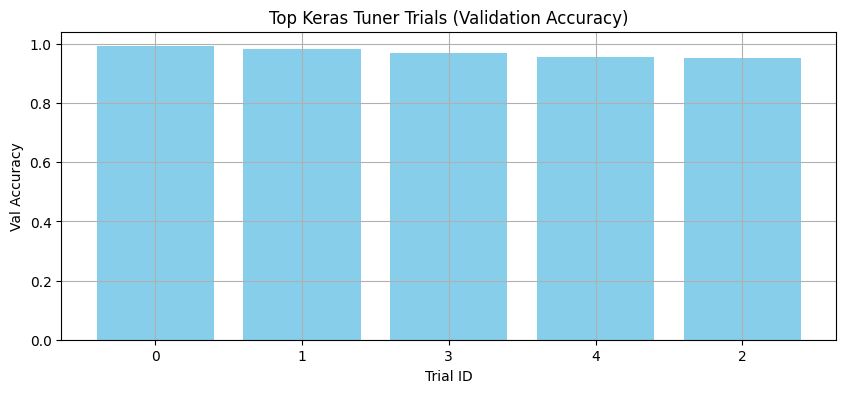

In [ ]:
plt.figure(figsize=(10, 4))
plt.bar(tuner_results["Trial"], tuner_results["Score"], color="skyblue")
plt.title("Top Keras Tuner Trials (Validation Accuracy)")
plt.ylabel("Val Accuracy")
plt.xlabel("Trial ID")
plt.grid(True)
plt.show()

## Confusion Matrix on Test Set

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step


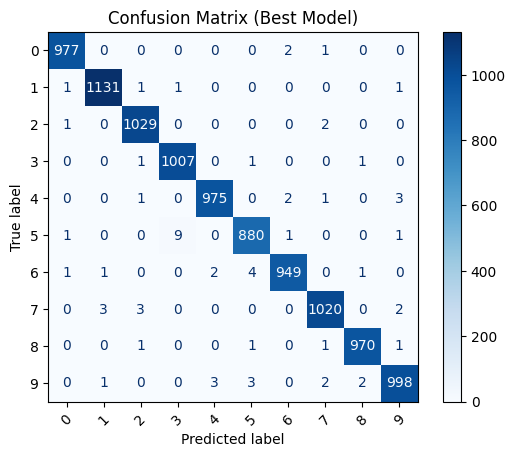

In [ ]:
y_pred = best_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix (Best Model)")
plt.grid(False)
plt.show()

## Summary
- Tuned filters, dense units, dropout, and learning rate
- Selected best model and evaluated it
- Visualized hyperparameter search
- Interpreted confusion matrix performance

Keras Tuner for Hyperparameter Optimization

📘 Overview

This Colab notebook demonstrates how to use Keras Tuner to optimize a CNN model's hyperparameters on the MNIST dataset. Keras Tuner enables automated hyperparameter search to improve model performance efficiently.

- Objective

To optimize the following hyperparameters using Random Search:

Number of filters in Conv2D layers

Units in Dense layer

Dropout rate

Learning rate

- Implementation Details

Dataset: MNIST

Model: CNN with two convolutional layers, a dense layer, and a dropout layer

Hyperparameters Tuned:

conv1_filters: [32, 64, 96, 128]

conv2_filters: [32, 64, 96, 128]

dense_units: [64, 128, 192, 256]

dropout_rate: [0.1, 0.2, 0.3, 0.4, 0.5]

learning_rate: [1e-2, 1e-3, 1e-4]

Search Algorithm: RandomSearch

Trials: 5

Validation Split: 20%

- Results

After tuning:

The best model is retrieved using tuner.get_best_models()

Final accuracy is evaluated on the test set

Best hyperparameters are printed
- Insights

Keras Tuner greatly simplifies experimentation by automating the search process

RandomSearch is fast for small spaces; use BayesianOptimization for smarter searching

Tuning even a few key parameters can lead to significant accuracy improvements
